# Building a room with Librosa 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from IPython import display
from megamicros_ailab.antenna import Antenna, Mu32_Mems32_JetsonNano_0001
from megamicros_ailab.room import arrange_2D
from megamicros_ailab.bmf import BeamformerDas2D
from megamicros_aidb.query.db import AidbSession
from megamicros.data import MuAudio
from megamicros.log import log

SAMPLING_FREQUENCY = 10000
FRAME_LENGTH = 512
ROOM_SIZE = (10, 12, 2.2)
ANTENNA_POSITION = (2, 5, 2.15)
#SOURCE_POSITION = (1, 1.5, 0.5)
SOURCE_POSITION = (1, 10.5, 0.5)

### Build the room
Desired reverberation time and dimensions of the room

In [2]:
rt60_tgt = 0.3  # seconds
room_dim = ROOM_SIZE  # meters

We invert Sabine's formula to obtain the parameters for the ISM simulator

In [3]:
e_absorption, max_order = pra.inverse_sabine(rt60_tgt, room_dim)

Create the room

In [4]:
#room = pra.ShoeBox(
#    room_dim, 
#    fs=SAMPLING_FREQUENCY, 
#    materials=pra.Material(e_absorption), 
#    max_order=max_order,
#    use_rand_ism = True, 
#    max_rand_disp = 0.05
#)

room = pra.ShoeBox(
    room_dim, 
    fs=SAMPLING_FREQUENCY
)

### Build the antenna


In [5]:
antenna_square: Antenna = Mu32_Mems32_JetsonNano_0001

Locate the antenna in the room

In [6]:
room.add_microphone_array( antenna_square.antenna( ANTENNA_POSITION ).T )

### Import signal

In [7]:
from scipy.io import wavfile
_, signal = wavfile.read("../guitar_16k.wav")

print( np.shape(signal) )

(166440,)


In [8]:
with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
    domains = session.load_domains()
    labels = session.load_labels( domain_id=1 )

    LABEL_ID = 15
    limit = 2
    channels = list( np.arange( 32 ) + 1 )
    audio = session.load_labelized( label_id=LABEL_ID, limit=limit, tags_id=5, channels=channels )

print( f"{len(audio)} section audio récupérées: " )
for idx, aud in enumerate( audio ):
    print( f"Audio[{idx}]: {aud} -> label={aud.label}, channels number: {aud.channels_number} ({aud.samples_number} samples)")
    
signal = audio[0][0][1]

I'm a NDarray signal with frame size = 12301 and frame number = 1
I'm a NDarray signal with frame size = 14401 and frame number = 1
2 section audio récupérées: 
Audio[0]: 32 X 12301 audio signals (sf=10000.0 Hz) -> label=piglet-squeals, channels number: 32 (12301 samples)
Audio[1]: 32 X 14401 audio signals (sf=10000.0 Hz) -> label=piglet-squeals, channels number: 32 (14401 samples)


In [9]:
ff = 1000
N = 2048
signal = np.cos(2*np.pi*ff*np.arange(N)/SAMPLING_FREQUENCY)

### Compute antenna response

In [10]:
source_position = SOURCE_POSITION
room.add_source( source_position, signal=signal, delay=1.3 )

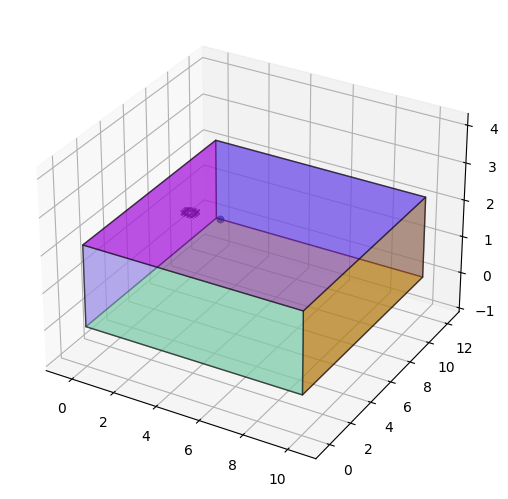

In [11]:
fig, ax = room.plot()
ax.set_xlim([-1, ROOM_SIZE[0]+1])
ax.set_ylim([-1, ROOM_SIZE[1]+1]);
ax.set_zlim([-1, ROOM_SIZE[2]+2]);

In [12]:
room.simulate()

### Show results

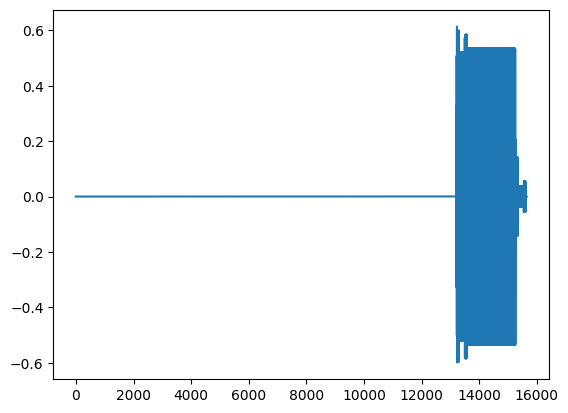

In [13]:
plt.plot(room.mic_array.signals[1,:])
plt.show()

In [14]:
display.display( display.Audio(signal, rate=SAMPLING_FREQUENCY ) )

Select 0 ans 1 mems of the beam F0. The source should be comming from the left

In [15]:
display.display( display.Audio([room.mic_array.signals[0,:], room.mic_array.signals[1,:]], rate=SAMPLING_FREQUENCY ) )

Select 0 ans 1 mems of the beam F2, that is 16 and 17th mems. Because of the position/orientation of the antenna, the source should be comming from the right:

In [16]:
display.display( display.Audio([room.mic_array.signals[16,:], room.mic_array.signals[17,:]], rate=SAMPLING_FREQUENCY ) )

### Compute the delay and sum weights for the beamformer

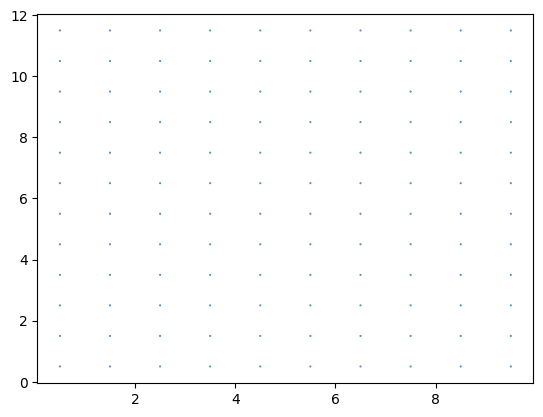

In [17]:
space_q = arrange_2D( ROOM_SIZE, sq_x=1, sq_y=1, ground_elevation=0.20 )
plt.scatter(space_q[:,0], space_q[:,1], space_q[:,2] )
plt.show()

In [18]:
bmf: BeamformerDas2D = BeamformerDas2D( antenna_square, space_q, ANTENNA_POSITION, SAMPLING_FREQUENCY, FRAME_LENGTH )

D= [[ 5.16214677  5.21497299  5.26795285 ...  5.66957893  5.68931431
   5.70961201]
 [ 4.96465097  5.01955608  5.07457656 ...  5.42843673  5.43802329
   5.44825378]
 [ 4.96465097  5.01955608  5.07457656 ...  5.36579214  5.36431704
   5.36351278]
 ...
 [ 8.70674217  8.66230588  8.61805821 ...  8.15427037  8.11642146
   8.07884084]
 [ 9.37055811  9.32928418  9.28821443 ...  8.82133353  8.77952717
   8.73793278]
 [10.08996329 10.05164381 10.0135372  ...  9.5467128   9.5017839
   9.45702222]]


In [19]:
antenna_output: MuAudio = MuAudio( room.mic_array.signals, SAMPLING_FREQUENCY )
antenna_output.set_frame_size( FRAME_LENGTH )

I'm a NDarray signal with frame size = 15652 and frame number = 1


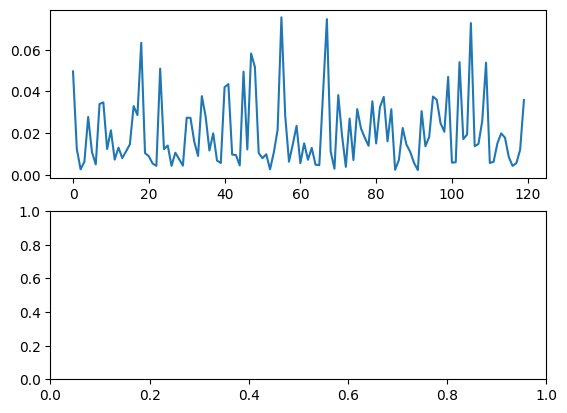

In [20]:
fig1, axes1 = plt.subplots(2, 1)

BF: np.ndarray = np.zeros( (len(space_q),) )
for idx, signal in enumerate( antenna_output ):
    BF += bmf.beamform( signal )

axes1[0].plot( BF )



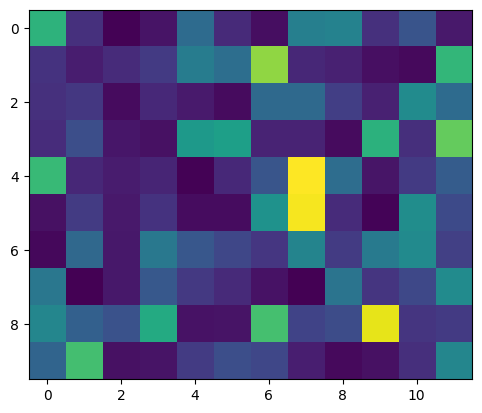

In [21]:
sq_x = 1
sq_y = 1
nx: int = int( ROOM_SIZE[0] * sq_x )
ny: int = int( ROOM_SIZE[1] * sq_y )

img = np.reshape( BF, (nx, ny) )
plt.imshow( img )